In [1]:
import pandas as pd
import numpy as np
from scipy import stats

np.random.seed(42)

data = {
    'Gender': np.random.choice(['Male', 'Female'], 100),                # Nominal (2 categories)
    'Preference': np.random.choice(['Product A', 'Product B', 'Product C'], 100), # Nominal (3 categories)
    'Age': np.random.randint(18, 70, 100),                             # Numeric
    'Spend_Amount': np.random.uniform(50, 500, 100)                    # Numeric
}
df = pd.DataFrame(data)

contingency_table = pd.crosstab(df['Gender'], df['Preference'])
print("--- Contingency Table ---")
print(contingency_table)
print()

# Observed frequencies
O = contingency_table.values

# Totals
row_totals = O.sum(axis=1)
col_totals = O.sum(axis=0)
grand_total = O.sum()

# Expected frequencies
expected = np.outer(row_totals, col_totals) / grand_total

# Chi-square statistic (Eq. 3.1)
chi_square_stat = np.sum(((O - expected) ** 2) / expected)

print(expected)

# Degrees of freedom
rows, cols = contingency_table.shape
dof = (rows - 1) * (cols - 1)


print("--- Chi-Square Test Results ---")
print(f"Chi-Square Statistic : {chi_square_stat:.4f}")
print(f"Degrees of Freedom  : {dof}")


--- Contingency Table ---
Preference  Product A  Product B  Product C
Gender                                     
Female             22         12         22
Male               13         14         17

[[19.6  14.56 21.84]
 [15.4  11.44 17.16]]
--- Chi-Square Test Results ---
Chi-Square Statistic : 1.6935
Degrees of Freedom  : 2


In [ ]:
#chi-square inference
from scipy.stats import chi2

alpha = 0.05
critical_value = chi2.ppf(1 - alpha, dof)
if chi_square_stat > critical_value:
    print("Since the calculated Chi-square value is greater than the critical value, we reject the null hypothesis.")
    print("This suggests there is a statistically significant association between Gender and Department.")
else:
    print("Since the calculated Chi-square value is less than or equal to the critical value, we fail to reject the null hypothesis.")
    print("This suggests there is no statistically significant association between Gender and Department.")

Since the calculated Chi-square value is less than or equal to the critical value, we fail to reject the null hypothesis.
This suggests there is no statistically significant association between Gender and Department.


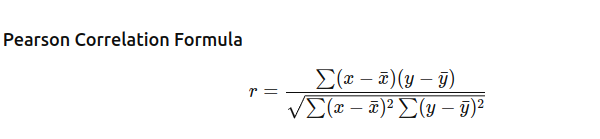

In [ ]:
# -----------------------------
# 3. Pearson Correlation (Numeric Data) – Manual
# -----------------------------
x = df['Age']
y = df['Spend_Amount']

# Means
x_mean = x.mean()
y_mean = y.mean()

# Numerator: Σ(x - x̄)(y - ȳ)
numerator = np.sum((x - x_mean) * (y - y_mean))

# Denominator: √[ Σ(x - x̄)² Σ(y - ȳ)² ]
denominator = np.sqrt(
    np.sum((x - x_mean) ** 2) * np.sum((y - y_mean) ** 2)
)

# Pearson correlation coefficient
r_val = numerator / denominator

print("--- Pearson Correlation (Manual) ---")
print(f"Correlation Coefficient (r): {r_val:.4f}")
print()

# using scipy
r_scipy, p_val_corr = stats.pearsonr(x, y)

print(f"r (SciPy)  : {r_scipy:.4f}")

if r_val == 0 :
  print("No linear relationship")
elif r_val < 0 :
  print("Negative Linear Relationsip")
else:
  print("Positive Linear Relationship")


--- Pearson Correlation (Manual) ---
Correlation Coefficient (r): -0.1355

r (SciPy)  : -0.1355
Negative Linear Relationsip
